# Marketing Experimentation & Growth Strategy

**Decision:** Does real randomized email assignment increase purchases, and does a learned targeting rule justify its complexity under a limited budget?

Hillstrom / MineThatData, 2008, 64,000 customers, three randomized arms, two-week outcomes. This notebook is executed research; all outputs are aggregates. Download the original locally using the README. No customer records or row-level predictions are printed. Costs/margins are hypothetical. See `docs/analysis-plan.md` for the retrospective frozen plan.

In [1]:
from pathlib import Path
import sys
import sqlite3
import numpy as np
import pandas as pd
from IPython.display import display, Image

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
from marketing_analytics.data import load, split, FEATURES, ARM_NAMES
from marketing_analytics.inference import contrasts
from marketing_analytics.models import (
    fit_propensity,
    fit_segment_values,
    incremental_policy,
    random_policy,
    propensity_policy,
    feature_frame,
)
from marketing_analytics.policy import evaluate_policy, evaluate_policy_difference

data = load(ROOT / "data/raw/hillstrom.csv")
display(
    pd.DataFrame(
        {
            "check": [
                "assigned customers",
                "missing cells",
                "identical full records beyond first",
                "positive purchase rows",
            ],
            "value": [
                len(data),
                int(data.isna().sum().sum()),
                int(data.duplicated().sum()),
                int(data.spend.gt(0).sum()),
            ],
        }
    )
)

,check,value
0,assigned customers,64000
1,missing cells,0
2,identical full records beyond first,6562
3,positive purchase rows,578


## Source quality and experimental denominator

All original customer rows are retained. Repeated full-field records are not confirmed duplicate customers: there is no customer identifier. `Surburban` is explicitly normalized to `Suburban`. Historical merchandise flags are not demographic labels. Conversion means purchase; visit is a distinct outcome.

In [2]:
with sqlite3.connect(":memory:") as db:
    data.to_sql("customers", db, index=False)
    summary = pd.read_sql_query((ROOT / "sql/01_campaign_summary.sql").read_text(), db)
summary["campaign"] = summary.action.map(ARM_NAMES)
display(summary)
expected = data.groupby("action")[["conversion", "visit", "spend"]].mean()
np.testing.assert_allclose(
    summary[["conversion_rate", "visit_rate", "spend_per_assigned_customer"]], expected, atol=1e-12
)

,action,assigned_customers,visitors,visit_rate,buyers,conversion_rate,spend_per_assigned_customer,historical_spend,recency_months,campaign
0,0,21306,2262,0.106167,122,0.005726,0.652789,240.882653,5.749695,No Email
1,1,21307,3894,0.182757,267,0.012531,1.422617,242.835931,5.773642,Men's Email
2,2,21387,3238,0.151400,189,0.008837,1.077202,242.536633,5.767850,Women's Email


## Primary hypothesis: conversion lift

Three pairwise comparisons per outcome; Holm correction within each outcome. Pointwise intervals do not share the same adjustment as Bonferroni simultaneous intervals. Spend and visits are secondary; cell analyses are exploratory.

,outcome,treatment,reference,n_t,n_c,mean_t,mean_c,effect,se,ci_low,ci_high,p_value,p_holm,sim_ci_low,sim_ci_high
0,conversion,1,0,21307,21306,0.012531,0.005726,0.006805,0.000921,0.005000,0.008610,1.523224e-13,4.569671e-13,0.004601,0.009010
1,conversion,2,0,21387,21306,0.008837,0.005726,0.003111,0.000823,0.001499,0.004723,1.571051e-04,3.142103e-04,0.001142,0.005080
2,conversion,1,2,21307,21387,0.012531,0.008837,0.003694,0.000995,0.001744,0.005644,2.051538e-04,3.142103e-04,0.001312,0.006076
3,visit,1,0,21307,21306,0.182757,0.106167,0.076590,0.003386,0.069954,0.083226,5.685165e-112,1.705550e-111,0.068484,0.084695
4,visit,2,0,21387,21306,0.151400,0.106167,0.045233,0.003234,0.038894,0.051572,3.182403e-44,6.364806e-44,0.037490,0.052976
5,visit,1,2,21307,21387,0.182757,0.151400,0.031356,0.003608,0.024285,0.038428,3.802165e-18,3.802165e-18,0.022719,0.039994
6,spend,1,0,21307,21306,1.422617,0.652789,0.769827,0.145247,0.485140,1.054515,1.163815e-07,3.491445e-07,0.422094,1.117560
7,spend,2,0,21387,21306,1.077202,0.652789,0.424412,0.130333,0.168957,0.679868,1.129397e-03,2.258794e-03,0.112385,0.736440
8,spend,1,2,21307,21387,1.422617,1.077202,0.345415,0.159617,0.032561,0.658268,3.046865e-02,3.046865e-02,-0.036721,0.727551


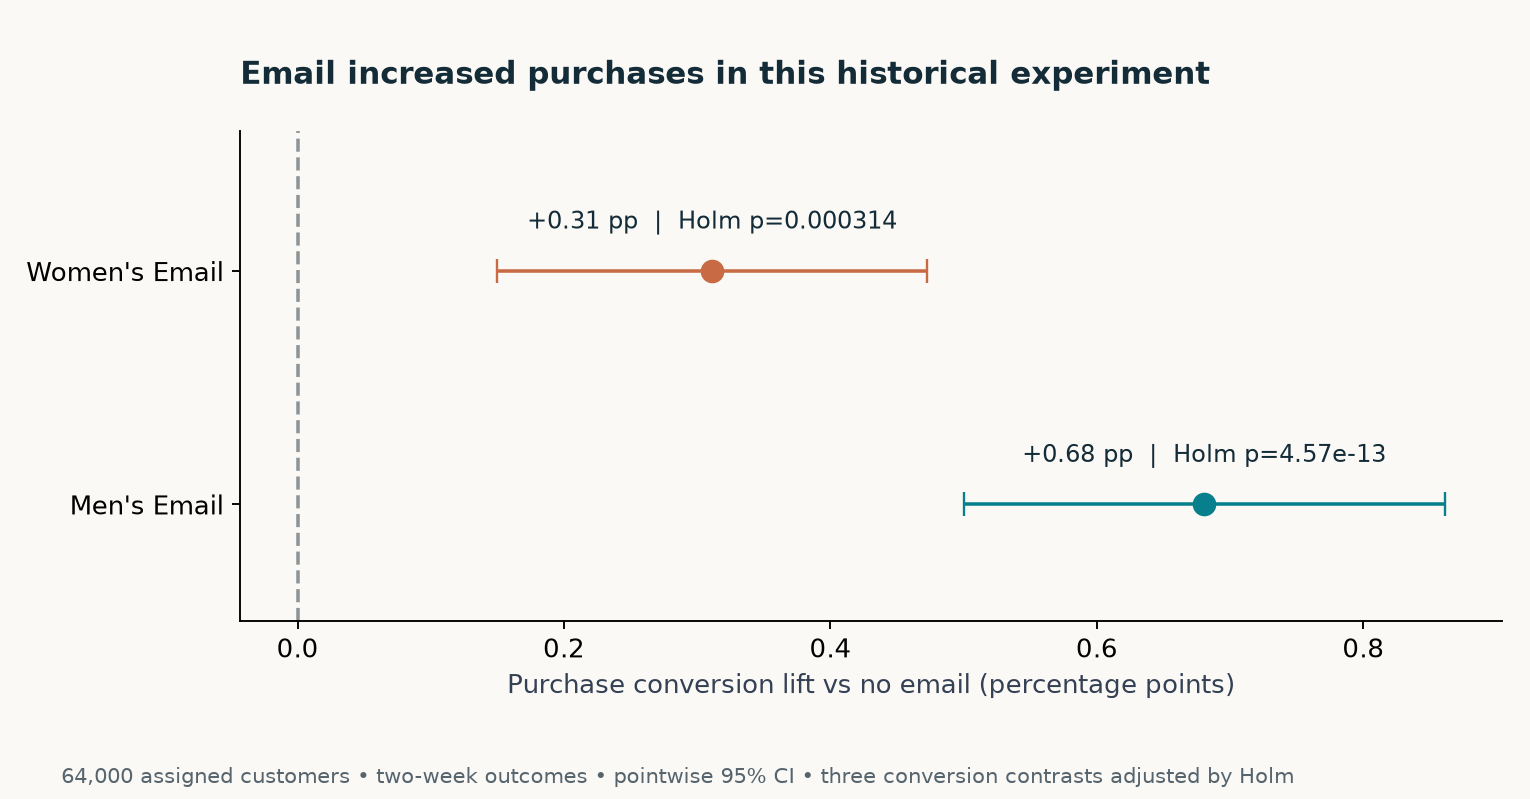

In [3]:
effects = contrasts(data)
display(effects)
published = pd.read_csv(ROOT / "reports/tables/campaign_contrasts.csv")
np.testing.assert_allclose(
    effects.select_dtypes("number"), published.select_dtypes("number"), rtol=1e-10, atol=1e-12
)
display(Image(filename=str(ROOT / "reports/figures/01_conversion_lift.png")))

## Fit rules using training rows only

Fixed seed 20080320; 32,000 train and 32,000 untouched test. Control-only logistic regression predicts natural purchasing. Segment rules shrink training spend means toward arm means with pseudo-count 1000. Neither the purchase model nor segment score is a verified individual causal effect. No selection or tuning uses test outcomes.

In [4]:
train, test = split(data)
assert set(train.index).isdisjoint(test.index)
model = fit_propensity(train)
lookup, training_cells = fit_segment_values(train)
x_test = test[FEATURES].copy()
policies = {
    "No Email": np.zeros(len(test), dtype=int),
    "Random Men (50%)": random_policy(x_test, 1, 0.5),
    "Purchase propensity Men (50%)": propensity_policy(model, x_test, 0.5),
    "Segment incremental (50%)": incremental_policy(
        lookup, x_test, capacity=0.5, margin=0.4, cost=0.02
    ),
}
display(training_cells)
from sklearn.metrics import roc_auc_score, brier_score_loss

control = test.loc[test.action.eq(0)]
predicted = model.predict_proba(feature_frame(control))[:, 1]
display(
    pd.DataFrame(
        {
            "held-out control metric": ["AUROC", "Brier", "constant training-rate Brier"],
            "value": [
                roc_auc_score(control.conversion, predicted),
                brier_score_loss(control.conversion, predicted),
                brier_score_loss(
                    control.conversion,
                    np.repeat(train.loc[train.action.eq(0)].conversion.mean(), len(control)),
                ),
            ],
        }
    )
)

,customer_segment,action,mean,count,shrunk_mean
0,Lapsed | Both,0,2.012121,462,1.085447
1,Lapsed | Both,1,1.567263,486,1.439760
2,Lapsed | Both,2,1.108994,477,1.094946
3,Lapsed | Men only,0,0.397037,2781,0.465878
4,Lapsed | Men only,1,0.943976,2749,1.059691
5,Lapsed | Men only,2,0.764066,2828,0.848753
6,Lapsed | Women only,0,0.332165,2794,0.417869
7,Lapsed | Women only,1,0.920175,2804,1.040474
8,Lapsed | Women only,2,1.044575,2802,1.056061
9,Recent | Both,0,0.610706,623,0.639429


,held-out control metric,value
0,AUROC,0.653720
1,Brier,0.006149
2,constant training-rate Brier,0.006158


## Design-based policy comparison

Horvitz–Thompson weights use the published 1/3 assignment probability, averaging over all evaluation customers. No-email actions cancel against the baseline. Compare policy differences on the same rows before estimating uncertainty; no-email is a zero *incremental* reference, not a business with zero sales.

,policy,incremental_spend,spend_se,spend_ci_low,spend_ci_high,incremental_conversion,conversion_se,conversion_ci_low,conversion_ci_high,email_fraction,assumed_contribution_per_10000
0,No Email,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.00000
1,Random Men (50%),0.434419,0.138039,0.163867,0.704970,0.002437,0.000928,0.000619,0.004256,0.5,1637.67500
2,Purchase propensity Men (50%),0.391960,0.158371,0.081558,0.702362,0.003094,0.001056,0.001023,0.005164,0.5,1467.84125
3,Segment incremental (50%),0.489641,0.148786,0.198025,0.781257,0.003469,0.001040,0.001431,0.005506,0.5,1858.56500


,incremental_spend,spend_se,spend_ci_low,spend_ci_high,incremental_conversion,conversion_se,conversion_ci_low,conversion_ci_high,email_fraction_a,email_fraction_b,email_fraction_difference
0,0.055222,0.161427,-0.261169,0.371614,0.001031,0.000988,-0.000905,0.002967,0.5,0.5,0.0


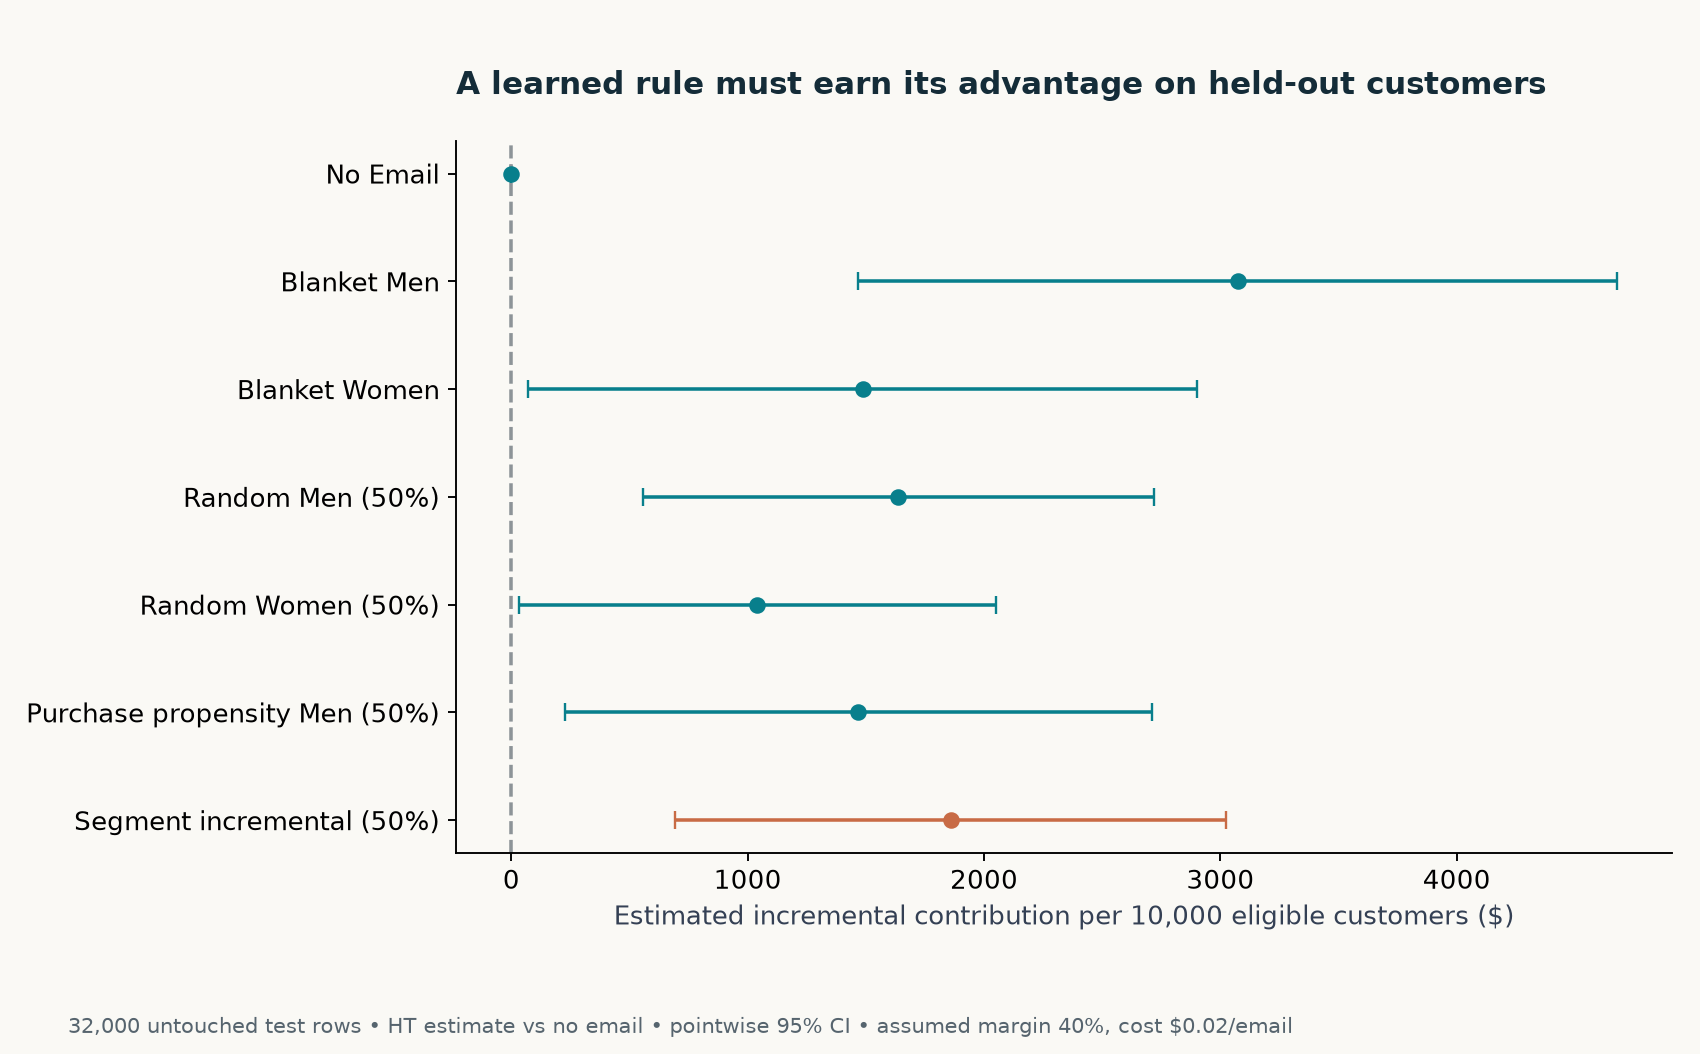

In [5]:
policy_results = pd.DataFrame(
    [{"policy": name, **evaluate_policy(test, actions)} for name, actions in policies.items()]
)
policy_results["assumed_contribution_per_10000"] = 10000 * (
    0.4 * policy_results.incremental_spend - 0.02 * policy_results.email_fraction
)
display(policy_results)
difference = evaluate_policy_difference(
    test, policies["Segment incremental (50%)"], policies["Random Men (50%)"]
)
display(pd.DataFrame([difference]))
assert difference["spend_ci_low"] < 0 < difference["spend_ci_high"]
display(Image(filename=str(ROOT / "reports/figures/05_policy_comparison.png")))

## Resource allocation and limitations

Cost, contribution margin and minimum contribution are assumptions. The 108 scenarios were fixed before outcome estimation; pointwise intervals do not permit selecting a proven winner from the grid. Capacity is an upper bound and rules may send nothing. Intervals omit training instability. Historical estimates need current validation.

,capacity,cost,maximum_email_budget_per_10000,email_fraction,email_cost_per_10000,expected_contribution_per_10000,contribution_ci_low_per_10000,contribution_ci_high_per_10000
12,0.25,0.00,0.0,0.250000,0.000,990.22875,183.780479,1796.677021
15,0.25,0.02,50.0,0.250000,50.000,940.22875,133.780479,1746.677021
18,0.25,0.10,250.0,0.250000,250.000,740.22875,-66.219521,1546.677021
21,0.25,0.50,1250.0,0.055375,276.875,253.57750,-365.373198,872.528198
48,0.50,0.00,0.0,0.500000,0.000,1958.56500,792.100408,3125.029592
51,0.50,0.02,100.0,0.500000,100.000,1858.56500,692.100408,3025.029592
54,0.50,0.10,500.0,0.500000,500.000,1458.56500,292.100408,2625.029592
57,0.50,0.50,2500.0,0.055375,276.875,253.57750,-365.373198,872.528198
84,1.00,0.00,0.0,1.000000,0.000,3526.42500,1892.155304,5160.694696
87,1.00,0.02,200.0,1.000000,200.000,3326.42500,1692.155304,4960.694696


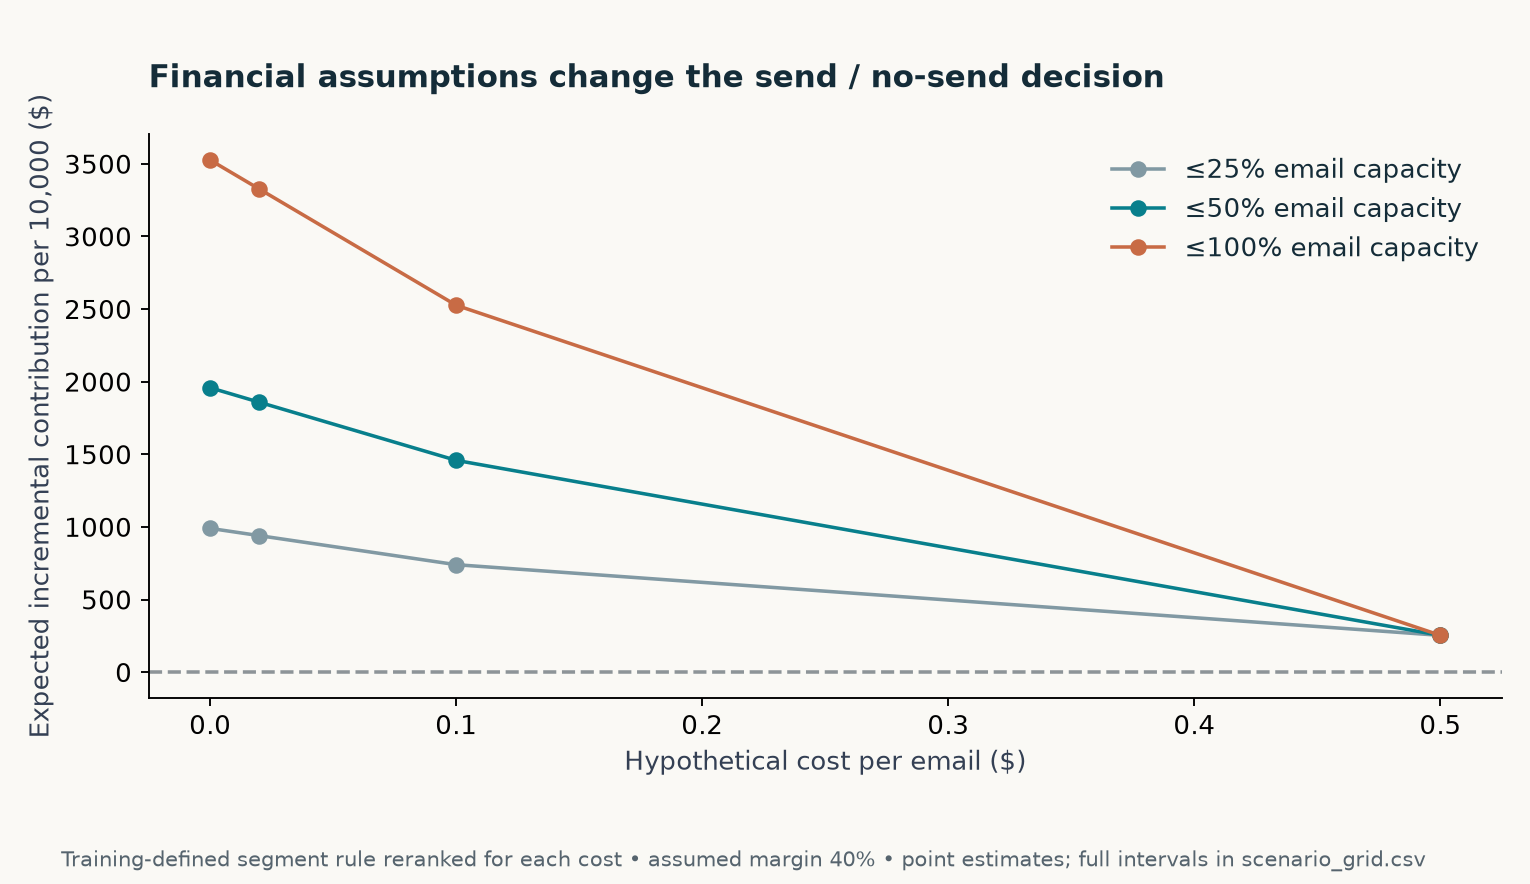

In [6]:
scenarios = pd.read_csv(ROOT / "reports/tables/scenario_grid.csv")
display(
    scenarios.loc[
        scenarios.margin.eq(0.4) & scenarios.minimum_net_contribution.eq(0),
        [
            "capacity",
            "cost",
            "maximum_email_budget_per_10000",
            "email_fraction",
            "email_cost_per_10000",
            "expected_contribution_per_10000",
            "contribution_ci_low_per_10000",
            "contribution_ci_high_per_10000",
        ],
    ]
)
display(Image(filename=str(ROOT / "reports/figures/06_budget_sensitivity.png")))

## Executive recommendation

Men is the stronger simple campaign benchmark in the historical primary conversion analysis. Segment targeting has no established incremental spend advantage over random Men at the same capacity, so personalization should be a challenger in a new experiment. Natural purchase likelihood does not identify customers whose purchases were caused by an email.

Run an equal-budget random Men vs segment policy experiment plus no-email control, freeze rules before assignment, capture actual contribution and delivery/unsubscribe guardrails, and size the test to a management-approved minimum worthwhile effect. Read the bilingual Executive Decision Memo for assumptions and risks. No real campaign, profit, or realized growth is claimed.